In [1]:
from diffusion_models.models import diffusion as dd
import pandas as pd
import numpy as np
from diffusion_models.utils import common_utils as ut
import arviz as az
import os

/home/rkm160630/anaconda3/envs/ds/lib/python3.10/site-packages/pymc/sampling/jax.py:39: UserWarning: This module is experimental.
  warnings.warn("This module is experimental.")


In [2]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

cpu


In [3]:
rotation_RT = pd.read_csv(f"data/rotation_rt.csv")
rotation_RT_n = rotation_RT.loc[~rotation_RT.isna().any(axis=1),:].to_numpy()#[0:1,:]

rotation_X = pd.read_csv(f"data/rotation_ra.csv")
rotation_X_n = rotation_X.loc[~rotation_RT.isna().any(axis=1),:].astype(int).to_numpy()#[0:1,:]

In [4]:
samples_n, tune, chains, acceptance_rate = 2000, 1000, 4,0.85

posterior_chain,_ = dd.sample_posterior_params(rotation_RT_n, rotation_X_n, 
samples_n,chains=chains, sampler="PYMC", tune=tune, acceptance_rate = acceptance_rate)


2023-02-01 18:32:52,751 - Common-Utils - DEBUG - [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]


DEBUG:Common-Utils:[v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]
Auto-assigning NUTS sampler...
INFO:pymc:Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
INFO:pymc:Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
INFO:pymc:Multiprocess sampling (4 chains in 4 jobs)
NUTS: [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]
INFO:pymc:NUTS: [v_m, v_s, v, a_m, a_s, a, z_m, z_s, z, ter_m, ter_s, t_er]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2751 seconds.
INFO:pymc:Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2751 seconds.


In [5]:
df_posterior_chain = ut.get_summary(posterior_chain)
df_posterior_chain

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,var_name,var_idx
0,1.140,2.277,-1.915,5.906,0.670,0.486,12.0,67.0,1.63,v_m,None
1,1.590,2.056,-1.825,6.328,0.345,0.267,28.0,52.0,1.20,v,"0, 0]"
2,1.180,2.611,-1.712,6.477,0.882,0.646,10.0,75.0,1.37,v,"1, 0]"
3,1.067,2.212,-2.052,6.277,0.522,0.375,14.0,56.0,1.61,v,"2, 0]"
4,1.403,2.222,-2.051,6.216,0.550,0.396,16.0,58.0,1.67,v,"3, 0]"
...,...,...,...,...,...,...,...,...,...,...,...
383,13510.979,64050.329,6.576,69631.436,13991.026,10034.193,5.0,14.0,2.75,t_er,"90, 0]"
384,12695.076,62373.351,5.786,78166.108,13188.657,9450.177,5.0,14.0,2.82,t_er,"91, 0]"
385,13057.334,62593.012,2.131,76586.709,13635.974,9778.799,5.0,15.0,2.79,t_er,"92, 0]"
386,12629.187,61730.792,4.788,72840.781,13102.573,9389.462,5.0,15.0,2.49,t_er,"93, 0]"


In [6]:
r_hat = ut.get_rhat(df_posterior_chain)
r_hat

,0,1,2,3,4,5,6,7,8,9,...,378,379,380,381,382,383,384,385,386,387
r_hat,1.63,1.2,1.37,1.61,1.67,1.67,1.65,1.84,1.42,1.23,...,2.61,2.68,2.89,2.8,2.57,2.75,2.82,2.79,2.49,2.59


In [7]:
posterior_chain

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [8]:
#posterior_chain = posterior_chain.sel(chain=[0,2,3])

In [9]:
az.summary(posterior_chain)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_m,1.904,2.140,-1.977,6.833,0.247,0.184,75.0,110.0,1.74
"v[0, 0]",1.971,2.249,-2.733,6.488,0.255,0.181,73.0,86.0,1.74
"v[1, 0]",2.117,2.363,-2.386,6.819,0.389,0.277,32.0,94.0,1.83
"v[2, 0]",1.686,2.234,-2.426,6.982,0.244,0.325,71.0,73.0,1.73
"v[3, 0]",2.040,2.226,-2.414,6.849,0.250,0.196,73.0,71.0,1.75
...,...,...,...,...,...,...,...,...,...
"t_er[90, 0]",18011.566,73410.622,6.576,100201.097,18476.853,13314.410,4.0,11.0,2.50
"t_er[91, 0]",16923.822,71525.671,5.786,111046.947,17423.479,12540.014,4.0,18.0,2.70
"t_er[92, 0]",17406.724,71752.235,2.131,110364.967,18010.867,12977.272,4.0,16.0,2.71
"t_er[93, 0]",16835.470,70783.823,4.788,104824.254,17307.036,12457.888,4.0,23.0,2.34


<AxesSubplot: ylabel='Density'>

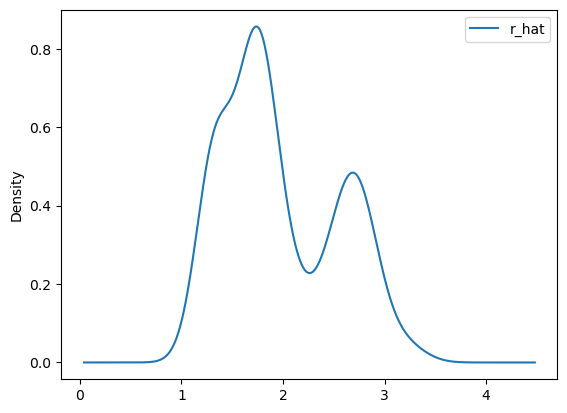

In [10]:
r_hat.T.plot(kind="kde")

In [11]:
#az.plot_trace(posterior_chain)

In [12]:
v_c_ch = ut.get_chains_for_param(posterior_chain,"v")
v_c_ch

,0,1,2
0,-0.135887,2.579213,2.547808
1,-0.567421,3.023010,2.395590
2,-0.118377,1.463402,1.068740
3,0.279009,2.388654,1.914536
4,-0.299426,1.982446,2.990798
...,...,...,...
189995,1.838228,1.475869,-1.199073
189996,2.754194,2.117451,-0.885474
189997,3.643148,3.025152,-1.015449
189998,2.217233,1.332258,-1.036708


<AxesSubplot: >

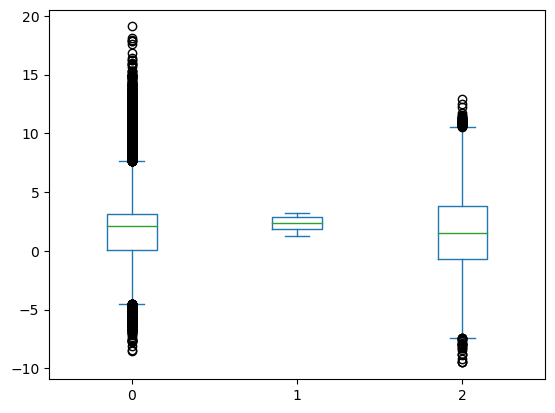

In [13]:
v_c_ch.plot(kind="box")

In [14]:
a_c_ch = ut.get_chains_for_param(posterior_chain,"a")
a_c_ch

,0,1,2
0,131.046204,24.204229,21.759825
1,231.729971,46.877925,34.276803
2,189.494618,17.748322,60.008862
3,237.218824,16.247594,57.220707
4,176.771660,13.240105,26.467771
...,...,...,...
189995,34.191483,32.513355,0.436899
189996,128.699885,13.133772,0.655489
189997,56.985187,15.272565,0.279697
189998,50.782073,23.604843,0.359852


<AxesSubplot: >

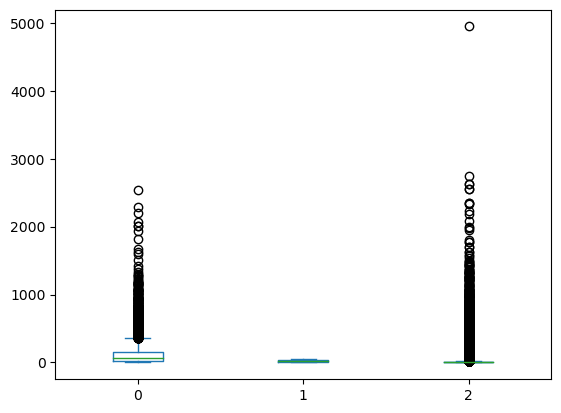

In [15]:
a_c_ch.fillna(0).plot(kind="box")

In [16]:
z_c_ch = ut.get_chains_for_param(posterior_chain,"z")
z_c_ch

,0,1,2
0,0.811762,0.722591,0.495723
1,0.814579,0.660512,0.512698
2,0.810222,0.628957,0.525072
3,0.825224,0.757591,0.516376
4,0.820021,0.794979,0.519961
...,...,...,...
189995,0.856534,0.825054,0.496055
189996,0.837875,0.822885,0.489297
189997,0.856006,0.865497,0.503639
189998,0.851497,0.852198,0.482115


<AxesSubplot: >

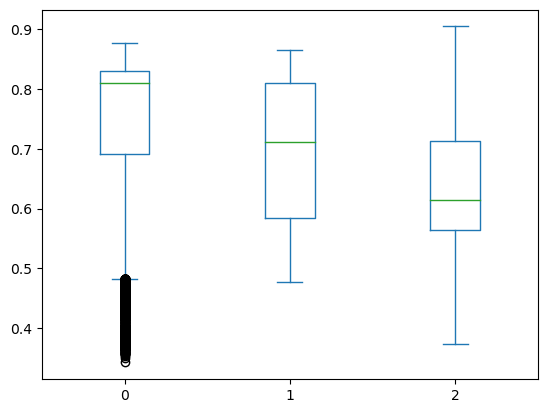

In [17]:
z_c_ch.fillna(0).plot(kind="box")

In [18]:
ter_c_ch = ut.get_chains_for_param(posterior_chain,"t_er")
ter_c_ch

,0,1,2
0,18.189936,2.007850,171.678707
1,18.055480,3.512089,167.027278
2,17.849230,5.635000,160.717491
3,17.924564,6.766781,187.595587
4,17.848262,2.541806,156.678652
...,...,...,...
189995,8.054293,6.575893,97631.770085
189996,7.219837,5.785715,109278.414492
189997,8.319515,2.130954,102547.610941
189998,6.569497,4.787854,103919.203239


<AxesSubplot: >

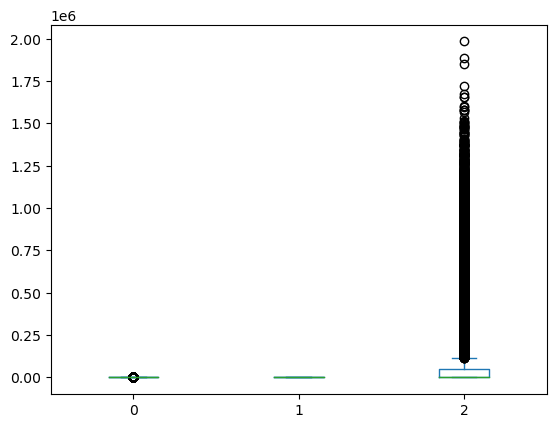

In [19]:
ter_c_ch.fillna(0).plot(kind="box")